# **Fundamentos de Aprendizaje por Refuerzo**
## **Q-Learning Algorithm**


In [1]:
import gymnasium

In [2]:
import pygame

In [3]:
import imageio

### **Liberías**

In [4]:
import numpy as np
import gymnasium as gym
import random
from collections import deque
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image


## **Visualización gráfica del entorno**

Entorno obtenido de: https://gymnasium.farama.org/environments/toy_text/cliff_walking/

## **Funcionamiento del entorno**

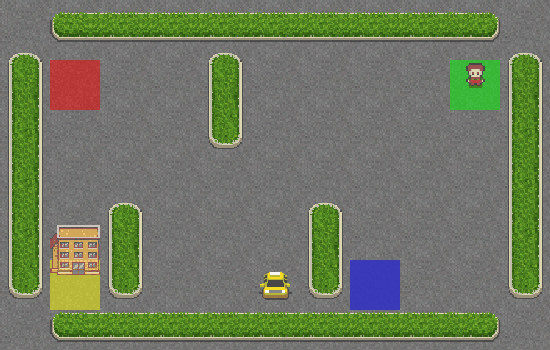

In [5]:
env = gym.make('Taxi-v4', render_mode="rgb_array")
state, _ = env.reset()
done = False
frames = []
for i in range(20):
    action = random.choice([0,1,2,3])  # Elegir una acción random
    next_state, reward ,done, _, _ = env.step(action)
    frame = env.render()
    frames.append(frame)
    state = next_state
env.close()
imageio.mimsave('taxi_env.gif', frames, fps=3)
Image(filename='taxi_env.gif')

## **Crear y observar el ambiente (estados y acciones)**

In [6]:
env = gym.make('Taxi-v4', render_mode="rgb_array")
num_states = env.observation_space.n
num_actions = env.action_space.n
print("Número de estados:", num_states)
print("Número de acciones:", num_actions)


Número de estados: 500
Número de acciones: 6


## **Q-Learning Implementation**

**Epsilon-Greedy Policy**

\begin{align}
a_t =
        \begin{cases}
        \text{random action} & \quad\text{with probability  }\epsilon \\
        \displaystyle\text{arg}\max_a{Q(s_t,:)}&\quad\text{with probability  }   1-\epsilon
        \end{cases}
\end{align}


**Q-learning Algorithm**


<img src="https://raw.githubusercontent.com/cdavid2804/test-1/main/Q_learning_Algorithm.png" alt="QL_Algorithm" width="600"/>

In [7]:

alpha = 0.7 # taza de aprendizaje
gamma = 0.995 # factor de descuento
epsilon = 0.1
num_episodes = 1000
episode_reward = deque(maxlen=num_episodes)

Q = np.zeros((num_states, num_actions))
np.random.seed(0)

# Política
def epsilon_greedy(state,epsilon):
  if np.random.rand() < epsilon:
    action = np.random.randint(num_actions)
  else:
    action = np.argmax(Q[state,:])
  return action

# Entrenamiento
for episode in range(num_episodes):
  state,_ = env.reset()
  done = False
  total_reward = 0
  steps = 0
  while not done:
    action = epsilon_greedy(state, epsilon)
    next_state, reward, done,_, _ = env.step(action)
    Q[state,action] = Q[state,action] + alpha*(reward + gamma*np.max(Q[next_state,:]) - Q[state,action])
    total_reward += reward
    state = next_state
    steps += 1
  episode_reward.append((episode, total_reward))
  print(f"Episodio:{episode}  Recompensa total:{total_reward}  Pasos por episodio:{steps}")

Episodio:0  Recompensa total:-635  Pasos por episodio:242
Episodio:1  Recompensa total:-2503  Pasos por episodio:1165
Episodio:2  Recompensa total:-194  Pasos por episodio:134
Episodio:3  Recompensa total:-1391  Pasos por episodio:548
Episodio:4  Recompensa total:-2139  Pasos por episodio:1017
Episodio:5  Recompensa total:-952  Pasos por episodio:370
Episodio:6  Recompensa total:-140  Pasos por episodio:143
Episodio:7  Recompensa total:-1832  Pasos por episodio:719
Episodio:8  Recompensa total:-995  Pasos por episodio:674
Episodio:9  Recompensa total:-240  Pasos por episodio:189
Episodio:10  Recompensa total:-300  Pasos por episodio:240
Episodio:11  Recompensa total:-262  Pasos por episodio:229
Episodio:12  Recompensa total:-54  Pasos por episodio:57
Episodio:13  Recompensa total:-962  Pasos por episodio:398
Episodio:14  Recompensa total:-216  Pasos por episodio:174
Episodio:15  Recompensa total:-269  Pasos por episodio:236
Episodio:16  Recompensa total:-227  Pasos por episodio:194
Epi

## **Gráfica de la recompensa total acumulada y recompensa promedio**

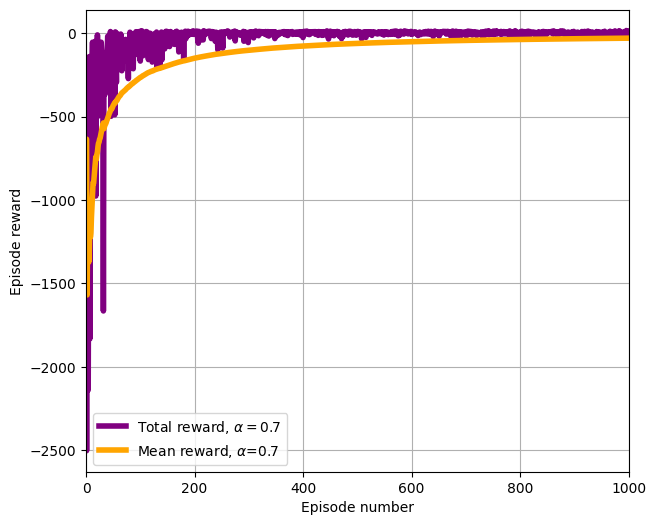

In [8]:
episodeReward = np.array(episode_reward)
episodes = episodeReward[:,0]
# Total rewards
rewards = episodeReward[:,1]
# Mean rewards
meanRewards = np.zeros(len(episodes))

for i in range(len(episodes)):
    if i == 0:
        meanRewards[0] = rewards[0]
    else:
        meanRewards[i] = np.mean(rewards[:i])
plt.figure(figsize=(7, 6))
plt.plot(episodes, rewards, label=r"Total reward, $\alpha=$"+str(alpha), linewidth=4, color='purple')
plt.plot(episodes, meanRewards, label=r"Mean reward, $\alpha$="+str(alpha), linewidth=4, color='orange')
plt.xlabel("Episode number")
plt.ylabel("Episode reward")
plt.xlim(0, num_episodes)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10)
plt.grid()
plt.legend()
plt.show()

## **Probar la política entrenada**

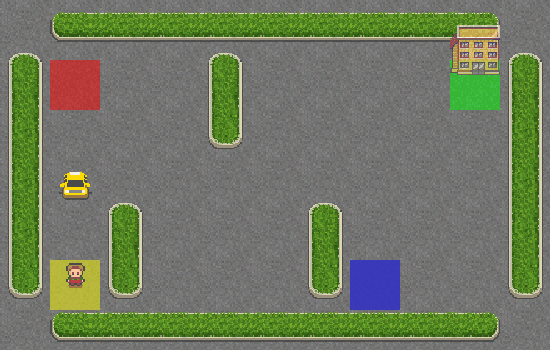

In [9]:
env = gym.make('Taxi-v4', render_mode="rgb_array")
state, _ = env.reset()
done = False
frames = []
for i in range(30):
    action = np.argmax(Q[state,:])  # Elegir la mejor acción según la tabla Q
    next_state, _, done, _, _ = env.step(action)
    frame = env.render()
    frames.append(frame)
    state = next_state
env.close()
imageio.mimsave('taxi_test.gif', frames, fps=3)
Image(filename='taxi_test.gif')

# Frozen Lake


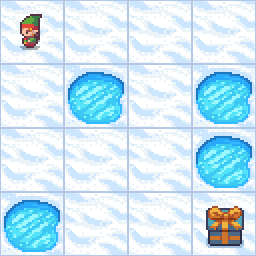

In [10]:
env = gym.make('FrozenLake-v1', render_mode="rgb_array")
state, _ = env.reset()
done = False
frames = []
for i in range(20):
    action = random.choice([0,1,2,3])  # Elegir una acción random
    next_state, reward ,done, _, _ = env.step(action)
    frame = env.render()
    frames.append(frame)
    state = next_state
env.close()
imageio.mimsave('FrozenLake_env.gif', frames, fps=3)
Image(filename='FrozenLake_env.gif')

## Crear y observar en ambiente


In [11]:
env = gym.make('FrozenLake-v1', render_mode="rgb_array")
num_states = env.observation_space.n
num_actions = env.action_space.n

print(f"Número de estados: {num_states}")
print(f"Número de acciones: {num_actions}")

Número de estados: 16
Número de acciones: 4


## Entrenamiento ##


In [12]:
alpha = 0.7
gamma = 0.99
epsilon = 0.1
num_episodes = 5000
episodes_reward = deque(maxlen=num_episodes)

Q = np.zeros((num_states, num_actions))
np.random.seed(0)

def epsilon_greedy(state, epsilon):
    if np.random.rand() < epsilon:
        action = np.random.randint(num_actions)
    else:
        action = np.argmax(Q[state, :])
    return action

def reward_function(state, action, next_state):
    if next_state in [5, 7, 11, 12]:
        reward = -100
    elif next_state == 15:
        reward = 100
    else:
        reward = -1
    return reward

# Entrenamiento
for episode in range(num_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0
    steps = 0
    while not done:
        action = epsilon_greedy(state, epsilon)
        next_state, _, done, _, _ = env.step(action)    
        reward = reward_function(state, action, next_state)
        Q[state, action] = Q[state, action] + alpha * (reward + gamma * np.max(Q[next_state, :]) - Q[state, action])
        total_reward += reward
        state = next_state
        steps += 1
    episodes_reward.append([episode, total_reward])
    print(f"Episode: {episode} | Total Reward: {total_reward} | Steps: {steps}")

env.close() 

Episode: 0 | Total Reward: -103 | Steps: 4
Episode: 1 | Total Reward: -115 | Steps: 16
Episode: 2 | Total Reward: -104 | Steps: 5
Episode: 3 | Total Reward: -112 | Steps: 13
Episode: 4 | Total Reward: -107 | Steps: 8
Episode: 5 | Total Reward: -112 | Steps: 13
Episode: 6 | Total Reward: -105 | Steps: 6
Episode: 7 | Total Reward: -114 | Steps: 15
Episode: 8 | Total Reward: -106 | Steps: 7
Episode: 9 | Total Reward: -109 | Steps: 10
Episode: 10 | Total Reward: -104 | Steps: 5
Episode: 11 | Total Reward: -113 | Steps: 14
Episode: 12 | Total Reward: -137 | Steps: 38
Episode: 13 | Total Reward: -113 | Steps: 14
Episode: 14 | Total Reward: -118 | Steps: 19
Episode: 15 | Total Reward: 89 | Steps: 12
Episode: 16 | Total Reward: -103 | Steps: 4
Episode: 17 | Total Reward: -111 | Steps: 12
Episode: 18 | Total Reward: -106 | Steps: 7
Episode: 19 | Total Reward: -104 | Steps: 5
Episode: 20 | Total Reward: -123 | Steps: 24
Episode: 21 | Total Reward: -102 | Steps: 3
Episode: 22 | Total Reward: -105

In [ ]:

env = gym.make('FrozenLake-v1', render_mode="rgb_array", is_slippery=False) 
state, _ = env.reset()
done = False
frames = []

while not done:  
    action = np.argmax(Q[state, :]) 
    next_state, reward, done, _, _ = env.step(action)
    frame = env.render()
    frames.append(frame)
    state = next_state
    

env.close()
imageio.mimsave('FrozenLake_env.gif', frames, fps=3)
Image(filename='FrozenLake_env.gif')